# Library Imports
Print python / package info and import libraries

In [19]:
import sys
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from sklearn.decomposition import PCA
from keras.models import Sequential
from keras.layers import Dense, LSTM
from keras.optimizers import Adam

import json
import datetime
import getpass

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Run config (edit before running)
run_config = {
    "run_id": "branch-name:commit-hash",
    "date_time": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "features_used": ["CDHI","CDNI","DHI","DNI","HOUR","TEMPERATURE"],
    "n_features": 6,
    "scaler": "MinMaxScaler",
    "use_pca": False,
    "pca_n_components": None,
    "learning_rate": globals().get("learning_rate", 0.0005),
    "optimizer": "Adam",
    "loss": "mae",
    "epochs": globals().get("setEpoch", 50),
    "batch_size": globals().get("batch_size", 32),
    "lstm_units": [50, 50],
    "seq_len": globals().get("seq_len", 24),
    "validation_split": 0.1,
    "random_seed": 42,
    "user": getpass.getuser(),
    "cwd": os.getcwd()
}

# Print only the key tuning params to keep output tidy
_tune_keys = ["features_used","n_features","learning_rate","optimizer","loss","epochs","batch_size","lstm_units","seq_len","validation_split","random_seed"]
print("Tuning / run config summary:")
print(json.dumps({k: run_config.get(k) for k in _tune_keys}, indent=2))

# Results record (fill after run)
results = {
    "run_id": run_config["run_id"],
    "training_time_s": None,
    "train_loss": None,
    "val_loss": None,
    "test_MAE": None,
    "test_MSE": None,
    "test_RMSE": None,
    "test_R2": None,
    "model_path": os.path.join(os.getcwd(), "Images", "model_run.h5"),
    "plot_path": os.path.join(os.getcwd(), "Images", "pred_plot.png"),
    "notes": ""
}

def save_run_record(run_config, results, out_dir=None):
    out_dir = out_dir or os.path.join(os.getcwd(), "Results")
    os.makedirs(out_dir, exist_ok=True)
    ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    path = os.path.join(out_dir, f"run_{ts}.json")
    with open(path, "w") as f:
        json.dump({"config": run_config, "results": results}, f, indent=2)
    print("Saved run record to", path)

# New: save a plain-text tuning summary into Images/
def save_tuning_summary(run_config, results, out_dir=None):
    out_dir = out_dir or os.path.join(os.getcwd(), "Images")
    os.makedirs(out_dir, exist_ok=True)
    # include microseconds and MAE for a unique, informative filename
    ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S_%f")
    mae = results.get("test_MAE")
    mae_tag = f"_mae{mae:.4f}" if mae is not None else ""
    path = os.path.join(out_dir, f"tuning_summary_{ts}{mae_tag}.txt")
    with open(path, "w", encoding="utf-8") as f:
        f.write("Run tuning summary\n")
        f.write("="*48 + "\n\n")
        f.write("Run config:\n")
        f.write(json.dumps(run_config, indent=2))
        f.write("\n\nResults:\n")
        f.write(json.dumps(results, indent=2))
        f.write("\n")
    print("Saved tuning summary to", path)
    return path

# Example usage (fill results then call save_run_record)
# results["training_time_s"] = 123.4
# results["test_MAE"] = mae_value
# save_run_record(run_config, results)

print('Python:', sys.version.splitlines()[0])
print('Executable:', sys.executable)
print('cwd:', os.getcwd())
print('Available CSVs:', glob.glob(os.path.join(os.getcwd(), '*.csv')))

import glob, os
print("Results:", glob.glob(os.path.join(os.getcwd(),"Results","run_*.json")))
print("Images:", glob.glob(os.path.join(os.getcwd(),"Images","*")))


Tuning / run config summary:
{
  "features_used": [
    "CDHI",
    "CDNI",
    "DHI",
    "DNI",
    "HOUR",
    "TEMPERATURE"
  ],
  "n_features": 6,
  "learning_rate": 0.0005,
  "optimizer": "Adam",
  "loss": "mae",
  "epochs": 50,
  "batch_size": 32,
  "lstm_units": [
    50,
    50
  ],
  "seq_len": 24,
  "validation_split": 0.1,
  "random_seed": 42
}
Python: 3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]
Executable: c:\Users\nnaji\AppData\Local\Programs\Python\Python313\python.exe
cwd: c:\Users\nnaji\OneDrive\Documents\GitHub\UGRA_LSTM_Solar-Prediction\File Versions py files
Available CSVs: ['c:\\Users\\nnaji\\OneDrive\\Documents\\GitHub\\UGRA_LSTM_Solar-Prediction\\File Versions py files\\BigData.csv', 'c:\\Users\\nnaji\\OneDrive\\Documents\\GitHub\\UGRA_LSTM_Solar-Prediction\\File Versions py files\\MedData.csv', 'c:\\Users\\nnaji\\OneDrive\\Documents\\GitHub\\UGRA_LSTM_Solar-Prediction\\File Versions py files\\SmallData.csv']
Results: []
Image

## Parameters

In [20]:
learning_rate = 0.0005
setEpoch = 50
batch_size = 32

# explicit data folder and csv
data_dir = r"C:\Users\nnaji\OneDrive\Documents\GitHub\UGRA_LSTM_Solar-Prediction\File Versions py files"
csv_path = os.path.join(data_dir, 'BigData.csv')
assert os.path.isfile(csv_path), f"CSV not found: {csv_path}"
print('Loading dataset:', csv_path)


Loading dataset: C:\Users\nnaji\OneDrive\Documents\GitHub\UGRA_LSTM_Solar-Prediction\File Versions py files\BigData.csv


## Load data

In [21]:
df = pd.read_csv(csv_path)
df.head()

,MONTH,DAY,HOUR,MINUTE,TEMPERATURE,WINDANGLE,WINDSPEED,ZENITH,CDHI,CDNI,DHI,DNI,CLOUD,POWER
0,1,1,0,0,10.1,261,4.7,170.95,0,0,0,0,7,0.0
1,1,1,0,30,10.3,261,4.8,168.57,0,0,0,0,6,0.0
2,1,1,1,0,10.4,260,5.0,163.66,0,0,0,0,7,0.0
3,1,1,1,30,10.3,259,4.9,157.84,0,0,0,0,6,0.0
4,1,1,2,0,10.2,258,4.9,151.69,0,0,0,0,6,0.0


## Exploratory plots (compact)
Time-series overview, heatmap and boxplots; remove or reduce these later if too many features.

In [22]:
# # quick overview: small figure set
# # These plots give a quick visual overview of the features and their correlations. Currently Commented out. 
# df.plot(subplots=True, figsize=(12, 8), title='Feature Time Series')
# plt.tight_layout()
# #plt.show()

# plt.figure(figsize=(8,6))
# sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
# plt.title('Feature Correlation Heatmap')
# #plt.show()


## Preprocessing: separate target, reshape, normalize

PCA reduced shape: (17520, 9)
Explained variance ratio (per PC): [0.35782014 0.1031635  0.09104578 0.08173935 0.07775868 0.07691203
 0.06561879 0.05628561 0.04188624]
Cumulative explained variance: [0.35782014 0.46098364 0.55202942 0.63376876 0.71152745 0.78843948
 0.85405827 0.91034388 0.95223012]


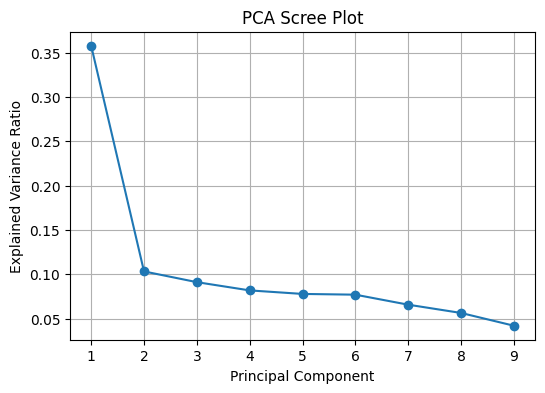

In [23]:
# PCA-based preprocessing
target_col = "POWER"

# select numeric features and separate target
numeric = df.select_dtypes(include=[np.number]).copy()
if target_col in numeric.columns:
    X = numeric.drop(columns=[target_col])
    y = numeric[target_col].copy()
else:
    X = numeric
    y = df[target_col] if target_col in df.columns else None

# standardize before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA: keep 95% variance (or use n_components=int(...) to fix number)
pca = PCA(n_components=0.95, svd_solver='full')
X_pca = pca.fit_transform(X_scaled)

print("PCA reduced shape:", X_pca.shape)
print("Explained variance ratio (per PC):", pca.explained_variance_ratio_)
print("Cumulative explained variance:", np.cumsum(pca.explained_variance_ratio_))

# DataFrame of principal components (optional, easier to inspect)
pc_cols = [f"PC{i+1}" for i in range(X_pca.shape[1])]
pca_df = pd.DataFrame(X_pca, columns=pc_cols, index=df.index)

# Replace feature matrix used downstream
solar_Xdata = pca_df.values            # shape (n_samples, n_components)
solar_ydata = y.values.reshape(-1, 1) if y is not None else None

# optional scree plot
plt.figure(figsize=(6,4))
plt.plot(np.arange(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, 'o-')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Scree Plot')
plt.grid(True)
plt.show()


## Create sequences for LSTM
Using 24 time steps as in your .py file

In [24]:
seq_len = 24
X, y_seq = [], []
for i in range(seq_len, len(solar_ydata)):
    X.append(solar_Xdata[i-seq_len:i, :])
    y_seq.append(solar_ydata[i, 0])
X = np.array(X)
y = np.array(y_seq)
print('X shape:', X.shape)
print('y shape:', y.shape)

# split
train_size = int(0.8 * len(y))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
print('train/test sizes:', X_train.shape[0], X_test.shape[0])


X shape: (17496, 24, 9)
y shape: (17496,)
train/test sizes: 13996 3500


## Build and train LSTM model

In [ ]:
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(LSTM(units=50))
model.add(Dense(units=1))

optimizer = Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss='mean_absolute_error')

history = model.fit(X_train, y_train, epochs=setEpoch, batch_size=batch_size, validation_split=0.1)
print('Training finished')


394/394 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 4.1573 - val_loss: 4.9586
Epoch 10/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 3.9410 - val_loss: 4.7885
Epoch 11/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 3.8163 - val_loss: 4.4754
Epoch 12/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 3.7405 - val_loss: 4.2324
Epoch 13/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 3.6590 - val_loss: 4.1773
Epoch 14/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 3.5790 - val_loss: 4.0853
Epoch 15/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 3.5366 - val_loss: 4.0594
Epoch 16/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 3.4910 - val_loss: 4.0494
Epoch 17/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 3.4494 - val_loss: 4.2370
Epoch 18/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 3.3849 - val_loss: 4.0343
Epoch 19/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 3.3393 - val_loss: 4.0753
Epoch 20/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 5s 

## Predict and evaluate

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
MAE: 5.2403390009880075

Run results summary:
{
  "run_id": "branch-name:commit-hash",
  "training_time_s": null,
  "train_loss": 2.6540238857269287,
  "val_loss": 4.232376575469971,
  "test_MAE": 5.2403390009880075,
  "test_MSE": null,
  "test_RMSE": null,
  "test_R2": null,
  "model_path": "c:\\Users\\nnaji\\OneDrive\\Documents\\GitHub\\UGRA_LSTM_Solar-Prediction\\File Versions py files\\Images\\model_run.h5",
  "plot_path": "c:\\Users\\nnaji\\OneDrive\\Documents\\GitHub\\UGRA_LSTM_Solar-Prediction\\File Versions py files\\Images\\pred_plot.png",
  "notes": ""
}


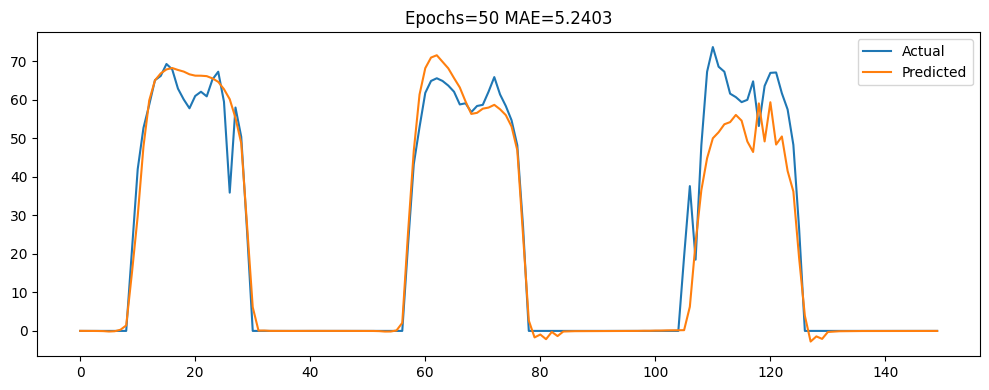

In [ ]:
y_pred = model.predict(X_test)
# Since we used PCA and StandardScaler, we need to inverse transform using the original y scaler if available.
# But here, y was not scaled, so we use the original values.
y_pred_orig = y_pred
y_test_orig = y_test.reshape(-1,1)

mae = mean_absolute_error(y_test_orig, y_pred_orig)
print('MAE:', mae)

# populate results dict with values available now
results["train_loss"] = history.history["loss"][-1] if "history" in globals() and "loss" in history.history else results.get("train_loss")
results["val_loss"] = history.history["val_loss"][-1] if "history" in globals() and "val_loss" in history.history else results.get("val_loss")
results["test_MAE"] = float(mae)
results["model_path"] = results.get("model_path")
results["plot_path"] = results.get("plot_path")

# Compute explicit Train MAE and re-print summary (ensure y_train / X_train exist)
from sklearn.metrics import mean_absolute_error
import numpy as np

# predict on train set to get explicit train MAE
y_train_pred = model.predict(X_train)
y_train_true = np.ravel(y_train)
y_train_pred = np.ravel(y_train_pred)

train_mae = mean_absolute_error(y_train_true, y_train_pred)
print(f"Train MAE: {train_mae:.4f}")
print(f"Test  MAE: {mae:.4f}")

# store into results
results["train_MAE"] = float(train_mae)
results["test_MAE"]  = float(mae)
print("\nUpdated results:")
print(json.dumps(results, indent=2))

# Print results summary
print("\nRun results summary:")
print(json.dumps(results, indent=2))

# Optionally save run record to Results/ (set run_config['auto_save']=True to enable automatic saving)
if run_config.get("auto_save", False):
    save_run_record(run_config, results)

plt.figure(figsize=(10,4))
plt.plot(y_test_orig[:150], label='Actual')
plt.plot(y_pred_orig[:150], label='Predicted')
plt.legend()
plt.title(f'Epochs={setEpoch} MAE={mae:.4f}')
plt.tight_layout()
plt.show()


## Save model outputs / figures

In [ ]:
out_dir = os.path.join(os.getcwd(), 'Images')
os.makedirs(out_dir, exist_ok=True)
fig_path = os.path.join(out_dir, f'pred_epoch{setEpoch}_mae{mae:.4f}.png')
plt.figure(figsize=(10,4))
plt.plot(y_test_orig[:150], label='Actual')
plt.plot(y_pred_orig[:150], label='Predicted')
plt.legend()
plt.title(f'Epochs={setEpoch} MAE={mae:.4f}')
plt.tight_layout()
plt.savefig(fig_path)
print('Saved:', fig_path)

# Save the human-readable tuning summary next to the figure
save_tuning_summary(run_config, results, out_dir=out_dir)

plt.close()

Saved: c:\Users\nnaji\OneDrive\Documents\GitHub\UGRA_LSTM_Solar-Prediction\File Versions py files\Images\pred_epoch50_mae5.2403.png
Saved tuning summary to c:\Users\nnaji\OneDrive\Documents\GitHub\UGRA_LSTM_Solar-Prediction\File Versions py files\Images\tuning_summary_20250926_161739_470339_mae5.2403.txt
